IMDB Movie Review using RNN (*Recurrent* Neural Network)

In [ ]:
# importing dependancies
from google.colab import drive
from nltk.tokenize import sent_tokenize, word_tokenize
from keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import LabelEncoder
from keras.utils import pad_sequences
from nltk.corpus import stopwords
import pandas as pd
import re
import nltk
from keras.models import Sequential
from keras.layers import Embedding
from keras.layers import SimpleRNN,Dense,Activation,LSTM,Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# connecting drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!ls /content/drive/MyDrive/Dataset/

 AmazonReview.csv     'IMDB Dataset.csv'
 AnimalsData	      'Student Mental health.csv'
 Churn_Modelling.csv  'Student Mental health.gsheet'
 Fish.csv


In [ ]:
# importing dataset
df = pd.read_csv("/content/drive/MyDrive/Dataset/IMDB Dataset.csv")

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.review[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [ ]:
# Data Cleaning function
stopword_list = stopwords.words("english")
def cleaning_data(para):
  para = sent_tokenize(text=para,language="english")
  TAG_RE = re.compile(r'<[^>]+>')
  i=0
  for line in para:
    line = TAG_RE.sub('', line)
    para[i] = re.sub(r"[^a-zA-Z0-9]"," ",line.lower())
    para[i] = " ".join([w for w in para[i].split() if w not in stopword_list])
    i+=1
  return para

In [ ]:
# on single data
cleaning_data(df.review[1])

['wonderful little production',
 'filming technique unassuming old time bbc fashion gives comforting sometimes discomforting sense realism entire piece',
 'actors extremely well chosen michael sheen got polari voices pat',
 'truly see seamless editing guided references williams diary entries well worth watching terrificly written performed piece',
 'masterful production one great master comedy life',
 'realism really comes home little things fantasy guard rather use traditional dream techniques remains solid disappears',
 'plays knowledge senses particularly scenes concerning orton halliwell sets particularly flat halliwell murals decorating every surface terribly well done']

In [ ]:

df.review = df.apply(lambda x: cleaning_data(x.review), axis=1)

In [ ]:
# cleaned data
df.head()

,review,sentiment
0,[one reviewers mentioned watching 1 oz episode...,positive
1,"[wonderful little production, filming techniqu...",positive
2,[thought wonderful way spend time hot summer w...,positive
3,[basically family little boy jake thinks zombi...,negative
4,[petter mattei love time money visually stunni...,positive


In [ ]:


# Checking total positives and negatives of sentiment column
df.sentiment.value_counts()

positive    25000
negative    25000
Name: sentiment, dtype: int64

In [ ]:
le = LabelEncoder()
df.sentiment = le.fit_transform(df.sentiment)

In [ ]:
df.head()

,review,sentiment
0,[one reviewers mentioned watching 1 oz episode...,1
1,"[wonderful little production, filming techniqu...",1
2,[thought wonderful way spend time hot summer w...,1
3,[basically family little boy jake thinks zombi...,0
4,[petter mattei love time money visually stunni...,1


In [ ]:
x = df.iloc[:,0]
y = df.iloc[:,-1]

In [ ]:
x

0        [one reviewers mentioned watching 1 oz episode...
1        [wonderful little production, filming techniqu...
2        [thought wonderful way spend time hot summer w...
3        [basically family little boy jake thinks zombi...
4        [petter mattei love time money visually stunni...
                               ...                        
49995    [thought movie right good job, creative origin...
49996    [bad plot bad dialogue bad acting idiotic dire...
49997    [catholic taught parochial elementary schools ...
49998    [going disagree previous comment side maltin o...
49999    [one expects star trek movies high art fans ex...
Name: review, Length: 50000, dtype: object

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.25)
print(len(xtrain))
print(len(ytrain))

37500
37500


In [ ]:
print(type(xtrain))
print(type(ytrain))
print(type(xtest))
print(type(ytest))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [ ]:
maxlen=20
data = pad_sequences([[0,1,2,3],[23,44],[34,55,99]], maxlen=maxlen)

In [ ]:
data

array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  1,  2,  3],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0, 23, 44],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0, 34, 55, 99]], dtype=int32)

In [ ]:
xtest

39216    [read tom robbins even cowgirls get blues teen...
41028    [comedy romance movie directed andy tennant st...
15503    [old horror movies interesting plenty screams ...
25208    [saw movie hbo really good tragic love story i...
13311    [green street called uk hooligans bad film, st...
                               ...                        
35734    [really suprised movie get higher rating imdb,...
25703    [really enjoyed film definitely keeps edge sea...
32719    [tried love movie, really, kevin bacon plays c...
14162    [radio true story man felt heart right thing, ...
16329    [madhur chandni bar started making realistic f...
Name: review, Length: 12500, dtype: object

In [ ]:
tokenizer = Tokenizer(num_words = 5000)
tokenizer.fit_on_texts(xtrain)
xtrain = tokenizer.texts_to_sequences(xtrain)

In [ ]:
# ans

In [ ]:
# df.review[0]

In [ ]:
# xtrain = df.apply(lambda x: tokenizer.texts_to_sequences(xtrain), axis=1)

In [ ]:
len(xtrain)

37500

In [ ]:
# xtest = df.apply(lambda x: tokenizer.texts_to_sequences(xtest), axis=1)
xtest = tokenizer.texts_to_sequences(xtest)

In [ ]:
len(xtest)

12500

In [ ]:
# maxlen=100
# da = pad_sequences(df['review'][0],padding='post',maxlen=maxlen)

In [ ]:
# da

In [ ]:
maxlen=100
xtrain = pad_sequences(xtrain,padding='post',maxlen=maxlen)
# df.review = df.apply(lambda x: pad_sequences(x.review,padding='post',maxlen=maxlen), axis=1)

In [ ]:
maxlen=100
xtest = pad_sequences(xtest,padding='post',maxlen=maxlen)

In [ ]:
# x = df.iloc[:,1]
# y = df.iloc[:,-1]

In [ ]:
# xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.25)
# print(len(xtrain))
# print(len(ytrain))

In [ ]:
# print(type(xtrain))
# print(type(ytrain))
# print(type(xtest))
# print(type(ytest))

In [ ]:
rnn = Sequential()

rnn.add(Embedding(5000,128,input_length=maxlen))
rnn.add(SimpleRNN(64))
rnn.add(Dense(1)) #flatten
rnn.add(Activation("sigmoid")) #using sigmoid for binary classification

print(rnn.summary())
rnn.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

# rnn = Sequential()

# rnn.add(Embedding(15000,32,input_length =5)) # num_words=15000
# rnn.add(SimpleRNN(16,input_shape = (15000,5),activation="relu"))
# rnn.add(Dense(1)) #flatten
# rnn.add(Activation("sigmoid")) #using sigmoid for binary classification

# print(rnn.summary())
# rnn.compile(loss="binary_crossentropy",optimizer="rmsprop",metrics=["accuracy"])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 128)          640000    
                                                                 
 simple_rnn (SimpleRNN)      (None, 64)                12352     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
 activation (Activation)     (None, 1)                 0         
                                                                 
Total params: 652,417
Trainable params: 652,417
Non-trainable params: 0
_________________________________________________________________
None


In [ ]:
history = rnn.fit(xtrain,ytrain,epochs = 5,validation_data = (xtest,ytest),batch_size=128)

Epoch 1/5
293/293 [==============================] - 56s 167ms/step - loss: 0.6919 - accuracy: 0.5217 - val_loss: 0.7290 - val_accuracy: 0.4713
Epoch 2/5
293/293 [==============================] - 36s 122ms/step - loss: 0.6864 - accuracy: 0.5449 - val_loss: 0.6800 - val_accuracy: 0.5599
Epoch 3/5
293/293 [==============================] - 37s 128ms/step - loss: 0.6663 - accuracy: 0.5790 - val_loss: 0.6680 - val_accuracy: 0.5717
Epoch 4/5
293/293 [==============================] - 32s 110ms/step - loss: 0.6764 - accuracy: 0.5590 - val_loss: 0.6824 - val_accuracy: 0.5671
Epoch 5/5
293/293 [==============================] - 35s 118ms/step - loss: 0.6710 - accuracy: 0.5814 - val_loss: 0.6660 - val_accuracy: 0.5814


In [ ]:
score = rnn.evaluate(xtest,ytest)

391/391 [==============================] - 5s 14ms/step - loss: 0.6660 - accuracy: 0.5814


In [ ]:
print("accuracy:", score[1]*100)

accuracy: 58.14399719238281


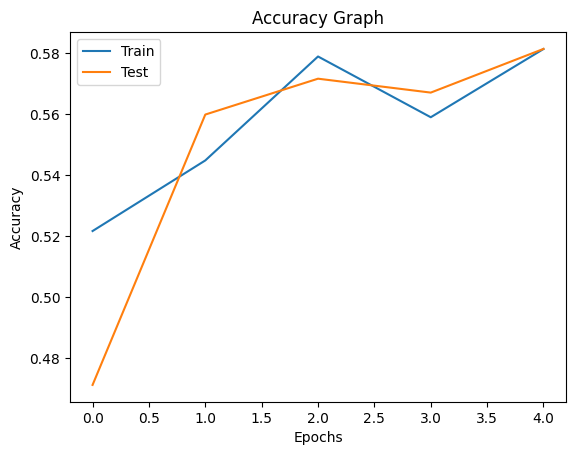

In [ ]:
plt.figure()
plt.plot(history.history["accuracy"],label="Train");
plt.plot(history.history["val_accuracy"],label="Test");
plt.title("Accuracy Graph")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show();

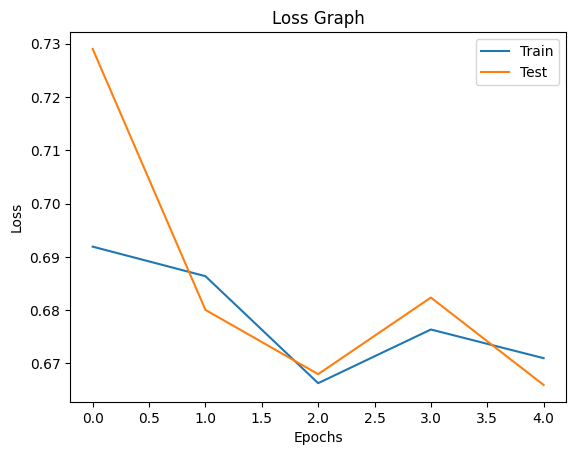

In [ ]:
plt.figure()
plt.plot(history.history["loss"],label="Train");
plt.plot(history.history["val_loss"],label="Test");
plt.title("Loss Graph")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show();

In [ ]:
# initilizing the basic variables
max_features=10000
max_len=100

In [ ]:
# BUILD MODEL
model = Sequential()
model.add(Embedding(max_features,128,input_length=max_len))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 100, 128)          1280000   
                                                                 
 lstm (LSTM)                 (None, 64)                49408     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1,329,473
Trainable params: 1,329,473
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history = model.fit(xtrain,ytrain,epochs = 5,validation_data = (xtest,ytest),batch_size=128)

Epoch 1/5
293/293 [==============================] - 25s 69ms/step - loss: 0.6938 - accuracy: 0.4998 - val_loss: 0.6932 - val_accuracy: 0.5003
Epoch 2/5
293/293 [==============================] - 5s 16ms/step - loss: 0.6934 - accuracy: 0.4999 - val_loss: 0.6932 - val_accuracy: 0.4998
Epoch 3/5
293/293 [==============================] - 4s 14ms/step - loss: 0.6934 - accuracy: 0.5019 - val_loss: 0.6931 - val_accuracy: 0.5003
Epoch 4/5
293/293 [==============================] - 4s 14ms/step - loss: 0.6933 - accuracy: 0.4947 - val_loss: 0.6934 - val_accuracy: 0.4998
Epoch 5/5
293/293 [==============================] - 3s 11ms/step - loss: 0.6934 - accuracy: 0.4974 - val_loss: 0.6932 - val_accuracy: 0.4998


In [ ]:
score,acc = model.evaluate(xtest,ytest,batch_size=32)
print("Score : ",score*100)
print("Accuracy : ",acc*100)

391/391 [==============================] - 1s 3ms/step - loss: 0.6932 - accuracy: 0.4998
Score :  69.31620240211487
Accuracy :  49.97600018978119


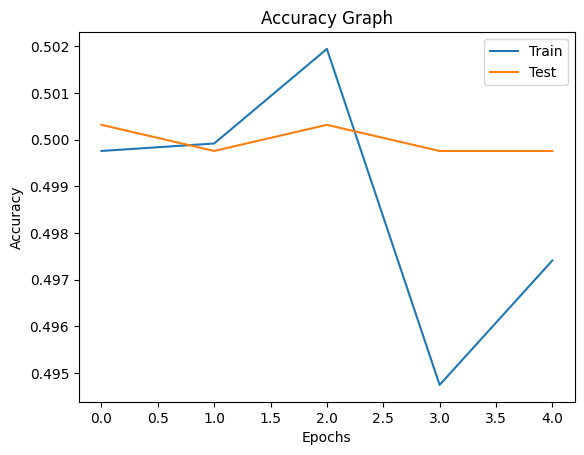

In [ ]:
plt.figure()
plt.plot(history.history["accuracy"],label="Train");
plt.plot(history.history["val_accuracy"],label="Test");
plt.title("Accuracy Graph")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show();

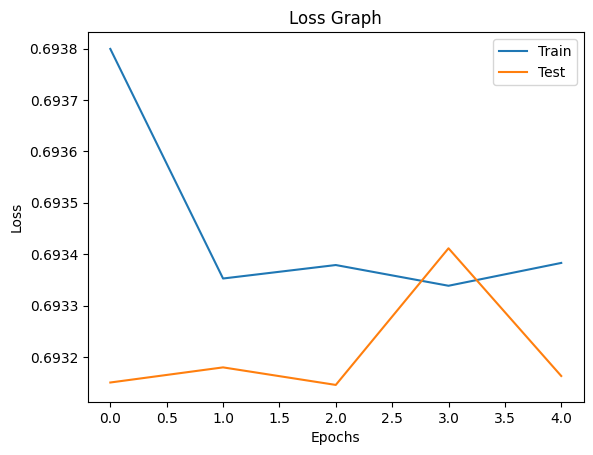

In [ ]:
plt.figure()
plt.plot(history.history["loss"],label="Train");
plt.plot(history.history["val_loss"],label="Test");
plt.title("Loss Graph")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show();